In [12]:
from matplotlib import pyplot as plt
import numpy as np
import h5py

import spectre

In [15]:
from spectre.Visualization.OpenVolfiles import open_volfiles
from spectre.Visualization.ReadH5 import list_observations
import glob
 
volfiles = glob.glob("ScalarWavePlaneWave1DEventsAndTriggersModVolume[0-1].h5")

vol_subfile_name = "/Fields"
obs_ids, obs_times = list_observations(open_volfiles(volfiles, vol_subfile_name))


In [16]:
import rich.columns
 
for volfile in open_volfiles(volfiles, vol_subfile_name, obs_ids[-1]):
    all_vars = volfile.list_tensor_components(obs_ids[-1])
    # Only look into the first file. The other should have the same variables.
    break
print("Valid Volume Coodinates:")
rich.print(rich.columns.Columns(all_vars))

IndexError: list index out of range

In [4]:
f = h5py.File("ScalarWavePlaneWave1DEventsAndTriggersBasicVolume0.h5")
# assert('Fields.vol' in f.keys(), "Missing `Fields` key, are you looking at volume data?")
data = np.array(f["Fields.vol"])
print(data[1])

ObservationId10025826642545393583


In [8]:
num_coords = 0
for volfile in open_volfiles(volfiles, vol_subfile_name):
    num_coords += len(volfile.get_tensor_component(obs_ids[1],'InertialCoordinates_x').data)
    
coords = np.ndarray((num_coords, len(obs_ids)))
phi = np.ndarray((num_coords, len(obs_ids)))
pi = np.ndarray((num_coords, len(obs_ids)))
psi = np.ndarray((num_coords, len(obs_ids)))

for i,volfile in enumerate(open_volfiles(volfiles, vol_subfile_name)):
    for j,id in enumerate(obs_ids):
        length =  len(volfile.get_tensor_component(id,'InertialCoordinates_x').data)
        if length!=num_coords/len(volfiles): continue
        coords[i*length:(i+1)*length,j] = volfile.get_tensor_component(id,'InertialCoordinates_x').data
        phi[i*length:(i+1)*length,j]    = volfile.get_tensor_component(id,'Phi_x').data
        pi[i*length:(i+1)*length,j]     = volfile.get_tensor_component(id,'Pi').data
        psi[i*length:(i+1)*length,j]    = volfile.get_tensor_component(id,'Psi').data
    

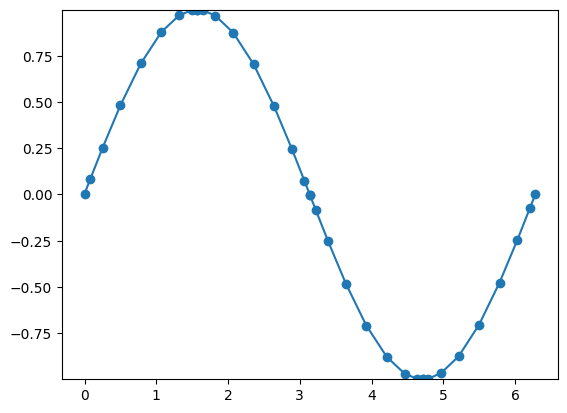

In [101]:

import matplotlib.animation as animation


# data = psi[:,::3] 
data = psi[:,:] 
x = np.sort(coords[:,3])

fig, ax = plt.subplots()
line, = ax.plot(x, data[:, 1], 'o-')  # 'o-' for dots connected by lines
ax.set_ylim(data.min(), data.max())  # Set y-limits to fit data

def update(frame):
    # if coords[0,frame] < 1e-10:
    #     line.set_ydata(data[:, frame])
    # else:
    #     line.set_ydata(data[[9,10,11,12,13,14,15,16,17,0,1,2,3,4,5,6,7,8], frame])
    # line.set_ydata(coords[np.argsort(coords[:,frame]), frame]/10)
    # line.set_ydata(coords[:, frame]/10)
    line.set_ydata(data[np.argsort(coords[:,frame]), frame])
    return line,

ani = animation.FuncAnimation(fig, update, frames=data.shape[1], blit=True, interval=200)


ani.save('3d_animation.gif', writer='pillow', fps=15)


In [14]:
# from spectre.Visualization.Render1D import plot_element
# for volfile in open_volfiles(volfiles, vol_subfile_name, obs_ids[-1]):
#     plot_element( ... )
#     break

In [73]:
psi[:,1]

array([ 0.00999983, -0.06867579, -0.24113705, -0.47080797, -0.70000048,
       -0.87264374, -0.96547456, -0.99606609, -0.99995   , -0.99995   ,
       -0.99763903, -0.97049107, -0.88223572, -0.71414238, -0.48835735,
       -0.26049735, -0.0886135 , -0.00999984,  0.99995   ,  0.99763903,
        0.97049107,  0.88223572,  0.71414238,  0.48835735,  0.26049735,
        0.0886135 ,  0.00999984, -0.00999983,  0.06867579,  0.24113705,
        0.47080797,  0.70000048,  0.87264374,  0.96547456,  0.99606609,
        0.99995   ])

In [9]:
coords[:,0]

array([0.        , 0.10073505, 0.32067793, 0.62101494, 0.94978138,
       1.2501184 , 1.47006127, 1.57079633, 1.57079633, 1.67153138,
       1.89147425, 2.19181127, 2.52057771, 2.82091473, 3.0408576 ,
       3.14159265, 4.71238898, 4.81312403, 5.03306691, 5.33340392,
       5.66217037, 5.96250738, 6.18245026, 6.28318531, 3.14159265,
       3.24232771, 3.46227058, 3.7626076 , 4.09137404, 4.39171105,
       4.61165393, 4.71238898])

In [10]:
1.57079633-1.67153138

-0.10073504999999994